In [ ]:
import json
import pathlib
import re

import pandas as pd

from tqdm.auto import tqdm

In [249]:
ROOT_DIR = pathlib.Path.cwd()
RAW_DATA_DIR = ROOT_DIR / "raw_data"
TREATED_DATA_DIR = ROOT_DIR / "treated_data"

EXTRACTED_DIR = RAW_DATA_DIR / "extracted"
RETRIEVED_DIR = RAW_DATA_DIR / "retrieved"
DATA_BLOCKS_DIR = TREATED_DATA_DIR / "data_blocks"
ROTATION_RESULTS_DIR = TREATED_DATA_DIR / "rotation_results"
CURATION_RESULTS_DIR = TREATED_DATA_DIR / "curation_results" / "rotation"

In [250]:
CONTRADICTION_REGEX = re.compile(
    r"""(
        false|wrong|incorrect|inaccurate|inconsistent|contradict
        |
        not\s+(?:true|correct|accurate|consistent|confirm)
    )""",
    re.VERBOSE
)

In [251]:
SOLVENT_SMILES = {
    r"Trichloro\(deuterio\)methane": "C(Cl)(Cl)(Cl)[2H]",
    "Trichloromethane": "C(Cl)(Cl)Cl",
    "Dichloromethane": "C(Cl)Cl",
    "Chloromethane": "CCl",
    "1,2-Dichloroethane": "ClCCCl",
    "Methanol": "CO",
    "Ethanol": "CCO",
    "Propan-2-ol": "CC(O)C",
    "Acetonitrile": "CC#N",
    "Propan-2-one": "CC(=O)C",
    "Diethyl ether": "CCOCC",
    "Benzene": "c1ccccc1",
    "Oxolane": "C1CCOC1",
    "Dimethyl sulfoxide": "CS(=O)C",
    "Ethyl acetate": "CC(=O)OCC",
    "Water": "O",
}

SOLVENT_IUPAC_NAMES = {
    "chcl3": "Trichloromethane",
    "cdcl3": r"Trichloro\(deuterio\)methane",
    "chloroform": "Trichloromethane",
    "ch2cl2": "Dichloromethane",
    "dcm": "Dichloromethane",
    "ch3cl": "Chloromethane",
    "clch2ch2cl": "1,2-Dichloroethane",
    "(ch2)2cl2": "1,2-Dichloroethane",
    "dichloroethane": "1,2-Dichloroethane",
    "ch3oh": "Methanol",
    "meoh": "Methanol",
    "ch3ch2oh": "Ethanol",
    "c2h5oh": "Ethanol",
    "etoh": "Ethanol",
    "isopropanol": "Propan-2-ol",
    "iproh": "Propan-2-ol",
    "i-proh": "Propan-2-ol",
    "acetone": "Propan-2-one",
    "ch3coch3": "Propan-2-one",
    "me2co": "Propan-2-one",
    "et2o": "Diethyl ether",
    "ch3cn": "Acetonitrile",
    "mecn": "Acetonitrile",
    "acn": "Acetonitrile",
    "accn": "Acetonitrile",
    "c6h6": "Benzene",
    "phh": "Benzene",
    "dmso": "Dimethyl sulfoxide",
    "tetrahydrofuran": "Oxolane",
    "thf": "Oxolane",
    "etoac": "Ethyl acetate",
    "acoet": "Ethyl acetate",
    "ch3cooet": "Ethyl acetate",
    "ch3cooc2h5": "Ethyl acetate",
    "ea": "Ethyl acetate",
    "h2o": "Water",
}
SOLVENT_IUPAC_NAMES.update(
    {name.lower().replace(" ", ""): name for name in SOLVENT_SMILES}
)


UNSIGNED_REAL = r"(?:[0-9]+(?:\.[0-9]+)?|[.][0-9]+)"
SIGNED_REAL = rf"[+-]?\s*{UNSIGNED_REAL}"


OPTICAL_ROTATION_BLOCK_PATTERN = re.compile(
    r"""
    \[\s*[αa]\s*\]                  # literal [α]
    (?P<rotation_info>              # capture rotation info
        [^D\(\[]*                   # run ahead to the next D
        D                           # sodium-D line (λ = 589 nm)
        [^\(\[]*                    # run ahead to the next parenthesis/bracket block
    )
    [\(\[]                          # opening parenthesis or bracket
        (?P<solvent_info>           # capture everything,
            (?:[^()\[\]]|\([^()]*\))*   # including nested parentheses
        )
    [\)\]]                          # closing parenthesis or bracket
    """,
    re.VERBOSE,
)

TEMPERATURE_PATTERN_LEFT = re.compile(
    rf"^({UNSIGNED_REAL}|rt|r\.t\.)(?:°C)?\s*D", re.IGNORECASE
)
TEMPERATURE_PATTERN_RIGHT = re.compile(
    rf"D\s*({UNSIGNED_REAL}|rt|r\.t\.)(?:°C)?[:=+\-\s]+", re.IGNORECASE
)
NO_TEMPERATURE_PATTERN = re.compile(r"D\s*[:=+\-]")

SEPARATOR_PATTERN = re.compile(r"(?:,|;|\bin\b|\bfor\b)+")
CONCENTRATION_PATTERN = re.compile(rf"^[cC][\.:]?(?:\s*=)?\s*({UNSIGNED_REAL})")
TEMPERATURE_IN_SOLVENT_PATTERN1 = re.compile(rf"T\s*=\s*({UNSIGNED_REAL})")
TEMPERATURE_IN_SOLVENT_PATTERN2 = re.compile(rf"({UNSIGNED_REAL})[\s]?[°o]C")

translation_table = str.maketrans("𝟎𝟏𝟐𝟑𝟒𝟓𝟔𝟕𝟖𝟗＋－˗", "0123456789+--")


def clean(s: str) -> str:
    return (
        s.translate(translation_table)
        .replace("  ", " ")
        .replace(", ", ",")
        .replace("\f", "")
        .replace("\n", "")
        .strip()
    )



ROTATION_PATTERN = re.compile(rf"([:=+\-])+\s*({UNSIGNED_REAL})")
ACCEPT_IMPLICIT_PLUS = True

def parse_rotation(s: str) -> float | None:
    match = ROTATION_PATTERN.search(s)
    if match is None:
        return None
    prefix = match.group(1).strip()
    if not (ACCEPT_IMPLICIT_PLUS or prefix[-1] in "+-"):
        return None
    return float(
        "-" * (prefix[-1] in "-") + match.group(2).strip()
    )  # implicit plus sign


D_TEMPERATURE_ROTATION_PATTERN = re.compile(
    rf"^\s*D\s*({UNSIGNED_REAL})\s*({SIGNED_REAL})\s*[°o]?$"
)
TEMPERATURE_D_ROTATION_PATTERN = re.compile(
    rf"^\s*({UNSIGNED_REAL})\s*D\s*({SIGNED_REAL})\s*[°o]?$"
)

def parse_rotation_info(rotation_info: str) -> tuple[float | None, float | None]:
    s = clean(rotation_info)
    match = TEMPERATURE_PATTERN_LEFT.search(s) or TEMPERATURE_PATTERN_RIGHT.search(s)
    if match is None:
        if NO_TEMPERATURE_PATTERN.search(s) is None:
            temperature = None
        else:
            temperature = 20.0
    elif match.group(1).lower() in ["rt", "r.t."]:
        temperature = 20.0  # https://en.wikipedia.org/wiki/Specific_rotation
    else:
        temperature = float(match.group(1))

    rotation = parse_rotation(s)

    if rotation is None or temperature is None:
        match = D_TEMPERATURE_ROTATION_PATTERN.search(
            s
        ) or TEMPERATURE_D_ROTATION_PATTERN.search(s)
        if match is not None:
            rotation = float(match.group(2))
            temperature = float(match.group(1))

    return rotation, temperature


def parse_concentration(s: str) -> tuple[float, str] | None:
    match = CONCENTRATION_PATTERN.search(s)
    if match is None:
        s = f"C={s}"
        match = CONCENTRATION_PATTERN.search(s)
    if match is None:
        return None
    if CONCENTRATION_PATTERN.search(s, match.end()) is not None:
        return None  # Accept only one concentration
    concentration = float(match.group(1))

    s = s[match.end() :].replace(" ", "").lower()
    match = re.search(r"^[x×·]10-(\d+)", s)
    if match is not None:
        concentration *= 10 ** -int(match.group(1))
        s = s[match.end() :]

    if s in ["", "g/100ml", "g/100cm3", "gm/100ml", "g/dl"]:
        return concentration, ""
    if s in ["mg/ml", "mg/cm3", "g/l"]:
        return concentration * 0.1, ""
    if s in ["g/ml", "g/cm3", "gcm-3"]:
        return concentration * 1000, ""

    s = s.replace("in", "").replace(" ", "")
    if s in SOLVENT_IUPAC_NAMES.keys():
        return concentration, SOLVENT_SMILES[SOLVENT_IUPAC_NAMES[s]]

    return None


def parse_solvent(s: str) -> str | None:
    s = s.lower().replace("in", "").replace(" ", "").replace("!", "").strip()
    return SOLVENT_SMILES.get(SOLVENT_IUPAC_NAMES.get(s, None), None)


def parse_temperature_in_solvent(s: str) -> float | None:
    match = TEMPERATURE_IN_SOLVENT_PATTERN1.search(
        s
    ) or TEMPERATURE_IN_SOLVENT_PATTERN2.search(s)
    return float(match.group(1)) if match else None


def parse_solvent_info(solvent_info: str) -> dict:
    s = clean(solvent_info)
    parsed_info = []
    fields = [field.strip() for field in SEPARATOR_PATTERN.split(s) if field.strip()]
    num_fields = len(fields)
    for field in fields:
        if (solvent := parse_solvent(field)) is not None:
            parsed_info.append(("solvent", solvent))
        elif (data := parse_concentration(field)) is not None:
            concentration, solvent = data
            if concentration is not None:
                parsed_info.append(("concentration", concentration))
            if solvent != "":
                parsed_info.append(("solvent", solvent))
                num_fields += 1
        elif (temperature := parse_temperature_in_solvent(field)) is not None:
            parsed_info.append(("temperature", temperature))

    # Check repetition of keys
    keys = [key for key, _ in parsed_info]
    if len(keys) != len(set(keys)):
        return dict()

    return dict(parsed_info)


def parse_optical_rotation(text: str) -> dict | None:
    match = OPTICAL_ROTATION_BLOCK_PATTERN.search(text)
    if match is None:
        return None
    d = match.groupdict()

    parsed_solvent_info = parse_solvent_info(d["solvent_info"])
    solvent = parsed_solvent_info.get("solvent", None)
    concentration = parsed_solvent_info.get("concentration", None)
    rotation, temperature = parse_rotation_info(d["rotation_info"])
    if temperature is None:
        temperature = parsed_solvent_info.get("temperature", None)
    return {
        "rotation": rotation,
        "temperature": temperature,
        "solvent": solvent,
        "concentration": concentration,
    }

In [252]:
def read_details(article_id: str) -> dict:
    with open(RETRIEVED_DIR / article_id / "details.json", "r") as f:
        return json.load(f)


def read_rotation_blocks(article_id: str, file_stem: str) -> dict:
    with open(DATA_BLOCKS_DIR / article_id / f"{file_stem}.json", "r") as f:
        return {
            block["start"]: block
            for block in json.load(f)
            if block["type"] == "rotation"
        }

In [253]:
curated_data = []
discarded_by_low_confidence = []
discarded_by_contradiction = []
discarded_at_rotation_parsing = []

article_id_prev = None
file_stem_prev = None
curated_output_paths = sorted(CURATION_RESULTS_DIR.glob("**/*.json"))
for path in tqdm(curated_output_paths, desc="Processing curated results"):
    if path.stat().st_size == 0:
        continue
    article_id = path.parent.parent.name
    file_stem = path.parent.name
    block_start = int(path.stem)

    if article_id != article_id_prev:
        details = read_details(article_id)
        article_id_prev = article_id

        if file_stem != file_stem_prev:
            rotation_blocks = read_rotation_blocks(article_id, file_stem)
            file_stem_prev = file_stem

    if block_start not in rotation_blocks:
        continue

    with open(path, "r") as f:
        blocks = json.load(f)

    for block in blocks:
        reasoning = block["reasoning"].lower()

        if block["major_isomer_confidence"] < 100:
            discarded_by_low_confidence.append((article_id, file_stem, block_start))
            continue

        molecule = block["molecule"]

        if block["excess_confidence"] == 100:
            if CONTRADICTION_REGEX.search(reasoning):
                discarded_by_contradiction.append((article_id, file_stem, block_start))
                continue
            excess = block["excess"]
        else:
            excess_recovery = block.get("excess_recovery", None)
            if excess_recovery is None or not excess_recovery["evident"]:
                discarded_by_low_confidence.append((article_id, file_stem, block_start))
                continue
            excess = excess_recovery["value"]

        rotation_text = rotation_blocks[block_start]["text"]
        rotation_data = parse_optical_rotation(rotation_text)
        if rotation_data is None or any(
            value is None for value in rotation_data.values()
        ):
            discarded_at_rotation_parsing.append((article_id, file_stem, block_start))
            continue

        data = {
            "figshare_id": article_id,
            "file_stem": file_stem,
            "block_start": block_start,
            "molecule": molecule,
            "smiles": block["smiles"],
            "rotation": rotation_data["rotation"],
            "temperature": rotation_data["temperature"],
            "solvent": rotation_data["solvent"],
            "concentration": rotation_data["concentration"],
            "excess": excess,
            "rotation_results": rotation_text,
            "doi": details.get("resource_doi", None),
            "license": details.get("license", {}).get("name", None),
        }
        curated_data.append(data)

num_discarded_by_low_confidence = len(discarded_by_low_confidence)
num_discarded_by_contradiction = len(discarded_by_contradiction)
num_discarded_at_rotation_parsing = len(discarded_at_rotation_parsing)
print(f"{num_discarded_by_low_confidence} were discarded by low confidence")
print(f"{num_discarded_by_contradiction} were discarded by contradiction")
print(f"{num_discarded_at_rotation_parsing} were discarded at rotation parsing")

Processing curated results:   0%|          | 0/99827 [00:00<?, ?it/s]

22150 were discarded by low confidence
287 were discarded by contradiction
1407 were discarded at rotation parsing


In [254]:
df = pd.DataFrame(curated_data)
df

,figshare_id,file_stem,block_start,molecule,smiles,rotation,temperature,solvent,concentration,excess,rotation_results,doi,license
0,10002857,ja9b08510_si_001,40372,"(S)-7-propyl-7,8-dihydro-6H-benzo[2,3]oxocino[...",C(CC)[C@H]1CC=2OC3=C(C2C2=C(OC1=O)C=CC=C2)C=CC=C3,-59.0,25.0,C(Cl)(Cl)Cl,0.2,99.0,"[α]25D -59.0 (c = 0.2, CHCl3)",10.1021/jacs.9b08510,CC BY-NC 4.0
1,10002857,ja9b08510_si_001,41279,"(S)-7-butyl-7,8-dihydro-6H-benzo[2,3]oxocino[5...",C(CCC)[C@H]1CC=2OC3=C(C2C2=C(OC1=O)C=CC=C2)C=C...,-46.0,25.0,C(Cl)(Cl)Cl,0.3,99.0,"[α]25D -46.0 (c = 0.3, CHCl3)",10.1021/jacs.9b08510,CC BY-NC 4.0
2,10002857,ja9b08510_si_001,42203,"(S)-7-pentyl-7,8-dihydro-6H-benzo[2,3]oxocino[...",C(CCCC)[C@H]1CC=2OC3=C(C2C2=C(OC1=O)C=CC=C2)C=...,-35.0,25.0,C(Cl)(Cl)Cl,0.3,99.0,"[α]25D -35.0 (c = 0.3, CHCl3)",10.1021/jacs.9b08510,CC BY-NC 4.0
3,10002857,ja9b08510_si_001,43112,"(S)-7-hexyl-7,8-dihydro-6H-benzo[2,3]oxocino[5...",C(CCCCC)[C@H]1CC=2OC3=C(C2C2=C(OC1=O)C=CC=C2)C...,-60.0,25.0,C(Cl)(Cl)Cl,0.2,99.0,"[α]25D -60.0 (c = 0.2, CHCl3)",10.1021/jacs.9b08510,CC BY-NC 4.0
4,10002857,ja9b08510_si_001,44038,"(S)-7-benzyl-7,8-dihydro-6H-benzo[2,3]oxocino[...",C(C1=CC=CC=C1)[C@H]1CC=2OC3=C(C2C2=C(OC1=O)C=C...,-20.0,25.0,C(Cl)(Cl)Cl,0.1,99.0,"[α]25D -20.0 (c = 0.1, CHCl3)",10.1021/jacs.9b08510,CC BY-NC 4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80287,9989909,ol9b03188_si_001,55004,"(S)-6-phenyl-2-(thiophen-2-yl)-5,6-dihydro-4H-...",C1(=CC=CC=C1)[C@@H]1CC(N=C(S1)C=1SC=CC1)=O,-42.6,25.0,C(Cl)(Cl)Cl,0.1,72.0,"[α]D25 = -42.6 (c 0.1, CHCl3)",10.1021/acs.orglett.9b03188,CC BY-NC 4.0
80288,9999668,ol9b03356_si_001,12487,(S)-3-(dibenzylamino)-3-(4-methoxyphenyl)propa...,C(C1=CC=CC=C1)N([C@@H](CCO)C1=CC=C(C=C1)OC)CC1...,-158.6,23.0,C(Cl)(Cl)Cl,2.0,96.0,"[α]D23 = - 158.6 (c = 2.0, CHCl3)",10.1021/acs.orglett.9b03356,CC BY-NC 4.0
80289,9999668,ol9b03356_si_001,16471,(3S)-3-(benzofuran-5-yl)-3-(dibenzylamino)prop...,O1C=CC2=C1C=CC(=C2)[C@H](CCO)N(CC2=CC=CC=C2)CC...,-185.4,23.0,C(Cl)(Cl)Cl,2.0,96.0,"[α]D23 = -185.4 (c = 2.0, CHCl3)",10.1021/acs.orglett.9b03356,CC BY-NC 4.0
80290,9999668,ol9b03356_si_001,17725,(S)-3-(dibenzylamino)-3-(thiophen-3-yl)propan-...,C(C1=CC=CC=C1)N([C@@H](CCO)C1=CSC=C1)CC1=CC=CC=C1,-143.2,23.0,C(Cl)(Cl)Cl,1.0,98.0,"[α]D23 = -143.2 (c = 1.0, CHCl3)",10.1021/acs.orglett.9b03356,CC BY-NC 4.0


<Axes: >

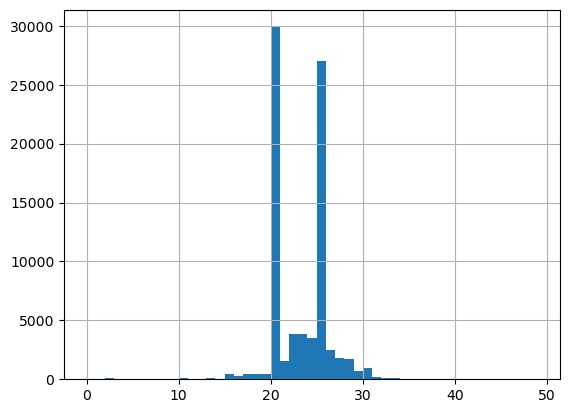

In [255]:
df.temperature.hist(bins=np.arange(0, 50, 1))

<Axes: >

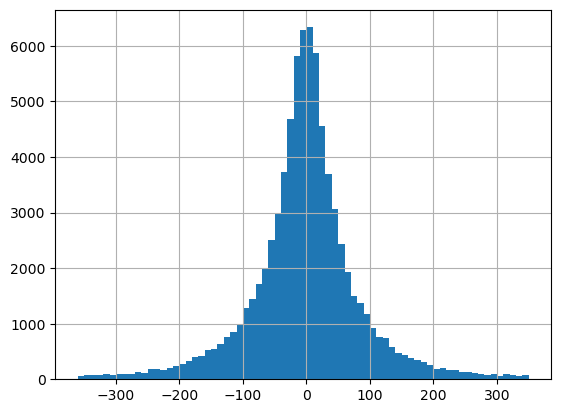

In [256]:
import numpy as np
df.rotation.hist(bins=np.arange(-360, 360, 10))

<Axes: >

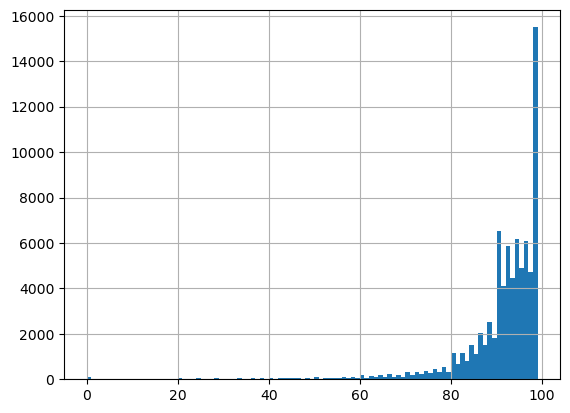

In [257]:
df.excess.hist(bins=np.arange(0, 100, 1))